---
## 1. Setup & Data Loading <a id='1'></a>

In [23]:
# Core Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot Style 
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

# Color Palette 
CHURN_COLORS  = {'No': '#2ecc71', 'Yes': '#e74c3c'}
PALETTE       = ['#2ecc71', '#e74c3c']

print(' Libraries loaded successfully')

 Libraries loaded successfully


In [ ]:
# Load Dataset 
data = pd.read_csv(r'C:\Users\ADMIN\OneDrive\Desktop\Customer Churn Prediction\Data\Raw\Telco-Customer-Churn.csv')

#  Fix TotalCharges (stored as string in raw dataset) 
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data = data.dropna(subset=['TotalCharges'])
data = data.drop(columns=['customerID'])   # non-predictive identifier

#  Binary target column for numeric analysis 
data['Churn_Binary'] = data['Churn'].map({'Yes': 1, 'No': 0})

print(f' Dataset loaded: {data.shape[0]:,} rows x {data.shape[1]} columns')

 Dataset loaded: 7,032 rows x 21 columns


---
## 2. Dataset Overview <a id='2'></a>

In [22]:
# Basic Info 
print('=== Shape ===')
print(f'Rows: {data.shape[0]:,}  |  Columns: {data.shape[1]}')

print('\n=== Data Types ===')
print(data.dtypes.value_counts())

print('\n=== Missing Values ===')
missing = data.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values ')

print('\n=== Duplicate Rows ===')
print(f'{data.duplicated().sum()} duplicates found')

=== Shape ===
Rows: 7,032  |  Columns: 21

=== Data Types ===
object     16
int64       3
float64     2
Name: count, dtype: int64

=== Missing Values ===
No missing values 

=== Duplicate Rows ===
22 duplicates found


In [4]:
#First look at the data 
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [5]:
# Statistical Summary 
data.describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_Binary
count,7032.00,7032.00,7032.00,7032.00,7032.00
mean,0.16,32.42,64.80,2283.30,0.27
std,0.37,24.55,30.09,2266.77,0.44
min,0.00,1.00,18.25,18.80,0.00
25%,0.00,9.00,35.59,401.45,0.00
50%,0.00,29.00,70.35,1397.48,0.00
75%,0.00,55.00,89.86,3794.74,1.00
max,1.00,72.00,118.75,8684.80,1.00


---
## 3. Target Variable Analysis <a id='3'></a>

=== Churn Distribution ===
  No: 5,163 customers (73.4%)
  Yes: 1,869 customers (26.6%)


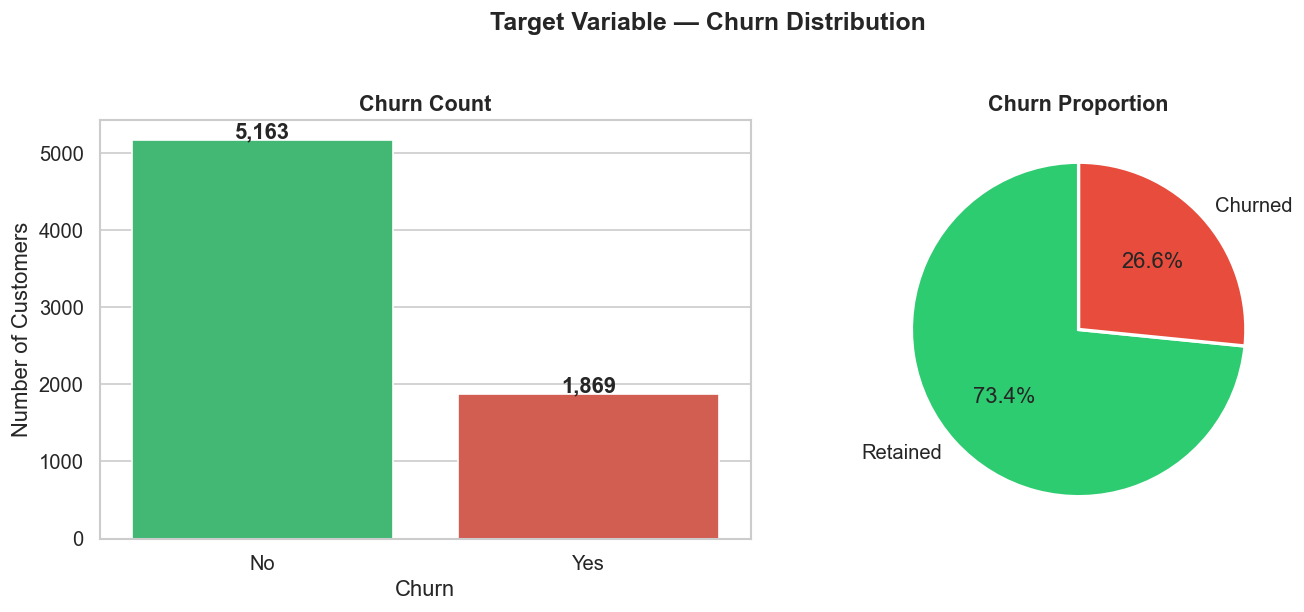

In [6]:
# Churn Distribution 
churn_counts = data['Churn'].value_counts()
churn_pct    = data['Churn'].value_counts(normalize=True) * 100

print('=== Churn Distribution ===')
for label in ['No', 'Yes']:
    print(f'  {label}: {churn_counts[label]:,} customers ({churn_pct[label]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Countplot
sns.countplot(x='Churn', data=data, palette=CHURN_COLORS, ax=axes[0], order=['No', 'Yes'])
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{int(bar.get_height()):,}', ha='center', fontweight='bold')
axes[0].set_title('Churn Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')

# Pie chart
axes[1].pie(churn_counts, labels=['Retained', 'Churned'],
            colors=PALETTE, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable — Churn Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Observation:** The dataset is imbalanced — ~26.5% of customers churned. This must be accounted for during model training using `class_weight='balanced'` or `scale_pos_weight`.

---
## 4. Continuous Feature Distributions <a id='4'></a>

In [7]:
# Identify continuous columns 
continuous_cols = [col for col in data.columns
                   if data[col].dtype in ['int64', 'float64']
                   and data[col].nunique() > 10
                   and col != 'Churn_Binary']
print('Continuous columns:', continuous_cols)

Continuous columns: ['tenure', 'MonthlyCharges', 'TotalCharges']


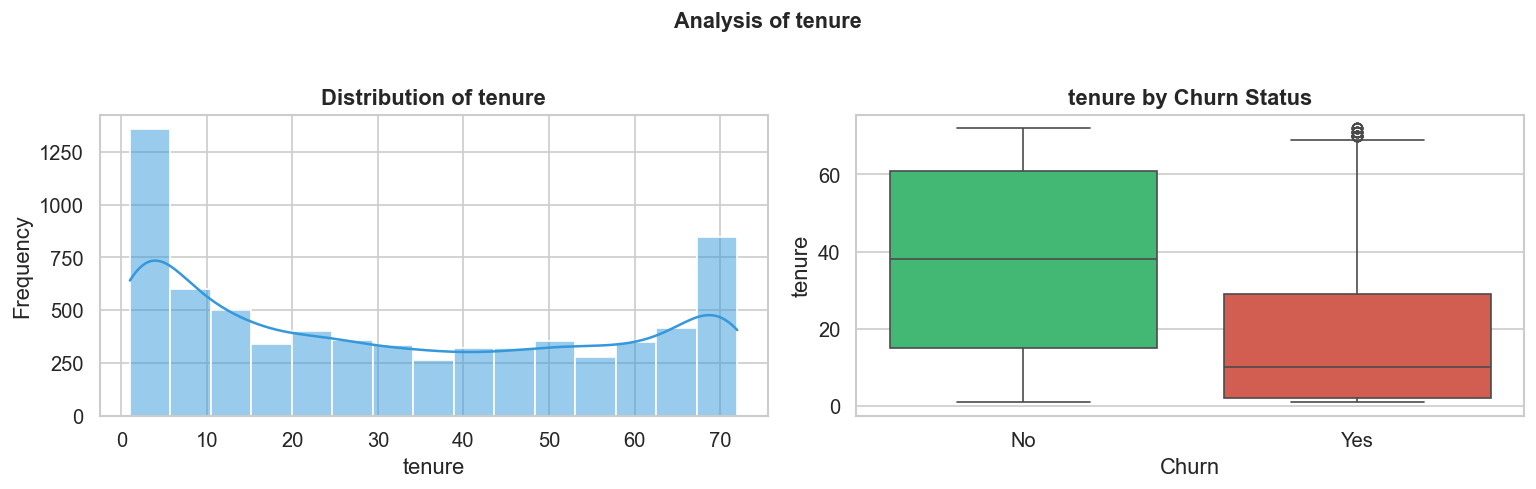

  Mean (Churned):  17.98
  Mean (Retained): 37.65



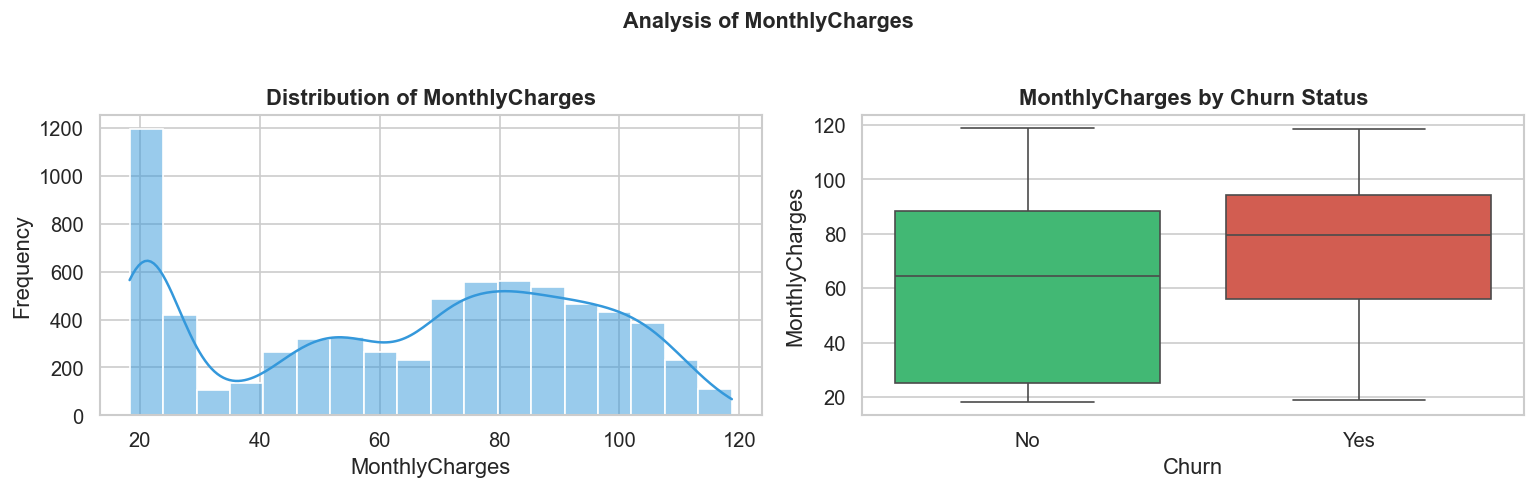

  Mean (Churned):  74.44
  Mean (Retained): 61.31



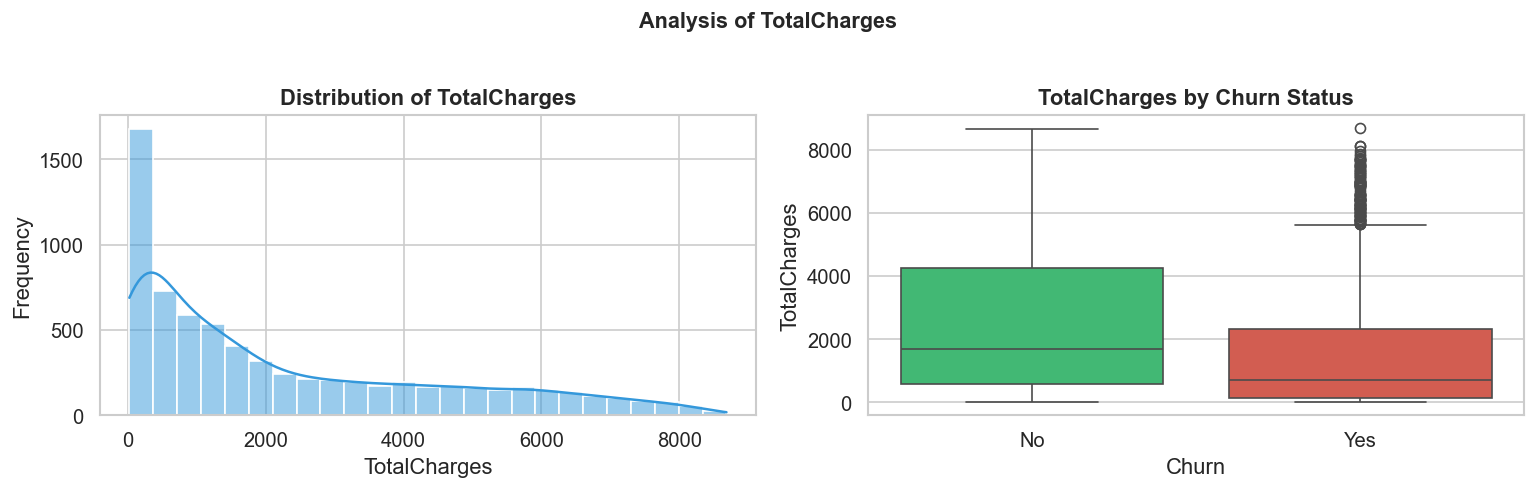

  Mean (Churned):  1531.80
  Mean (Retained): 2555.34



In [8]:
# Distribution + Boxplot side by side for each continuous col 
for col in continuous_cols:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Histogram with KDE
    sns.histplot(data[col], kde=True, ax=axes[0], color='#3498db')
    axes[0].set_title(f'Distribution of {col}', fontweight='bold')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # Boxplot split by Churn
    sns.boxplot(x='Churn', y=col, data=data,
                palette=CHURN_COLORS, order=['No', 'Yes'], ax=axes[1])
    axes[1].set_title(f'{col} by Churn Status', fontweight='bold')
    axes[1].set_xlabel('Churn')
    axes[1].set_ylabel(col)

    plt.suptitle(f'Analysis of {col}', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print(f'  Mean (Churned):  {data[data["Churn"]=="Yes"][col].mean():.2f}')
    print(f'  Mean (Retained): {data[data["Churn"]=="No"][col].mean():.2f}')
    print()

---
## 5. Categorical Feature Distributions <a id='5'></a>

In [9]:
#Identify categorical columns 
categorical_cols = [col for col in data.columns
                    if data[col].dtype == 'object'
                    and col != 'Churn']
print(f'Categorical columns ({len(categorical_cols)}):', categorical_cols)

Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


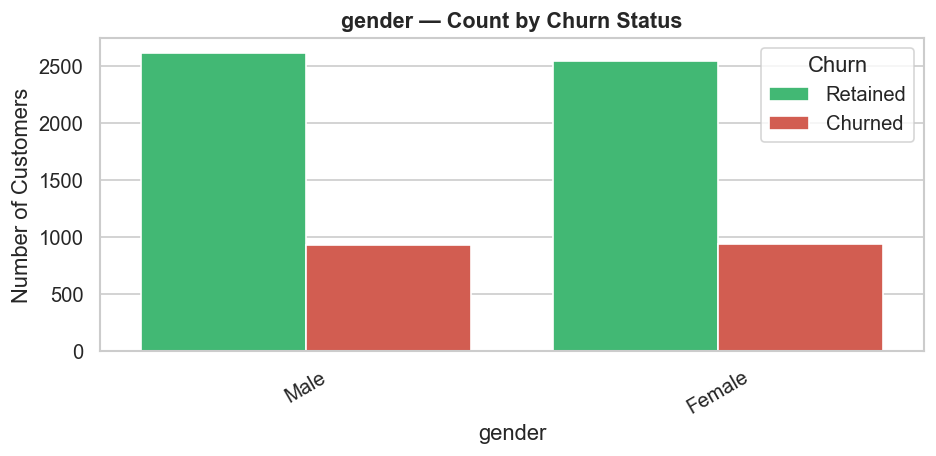

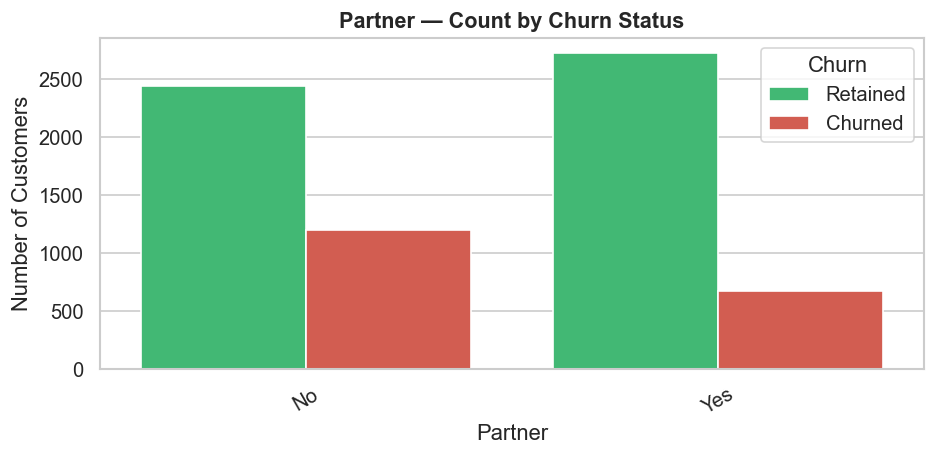

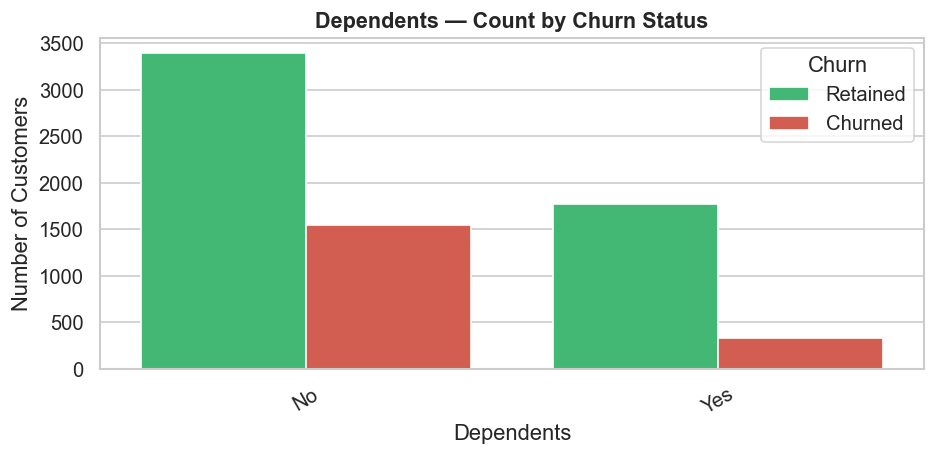

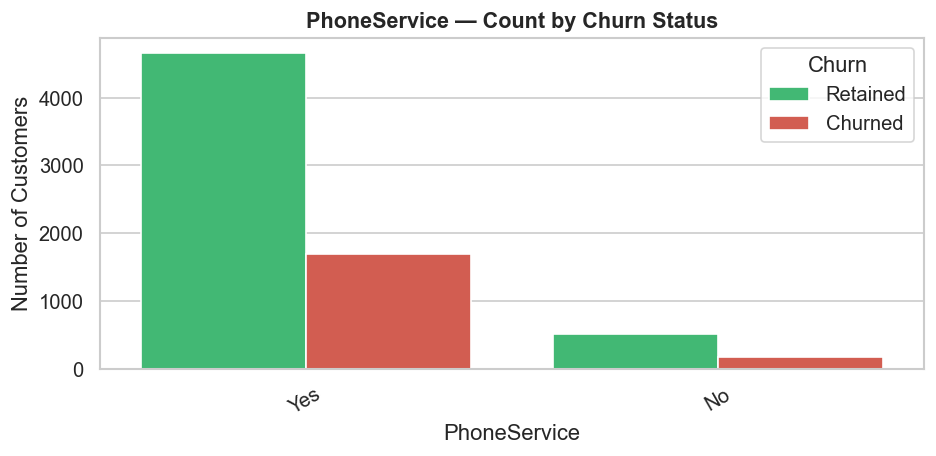

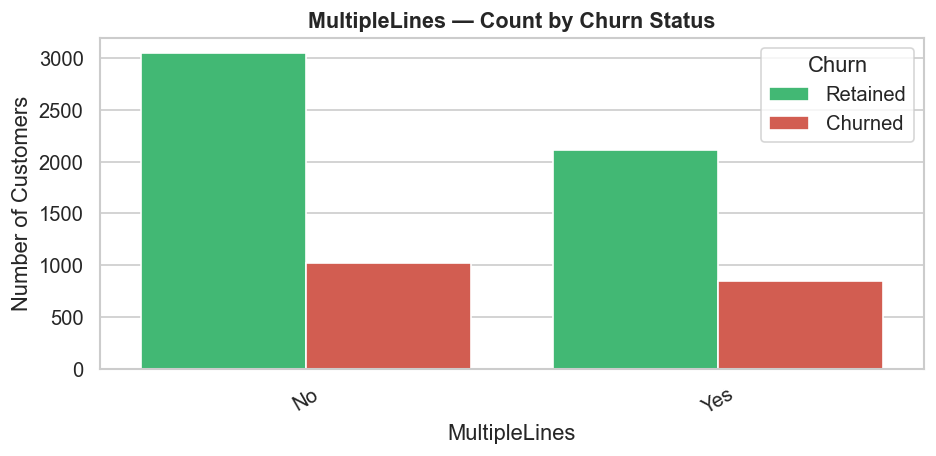

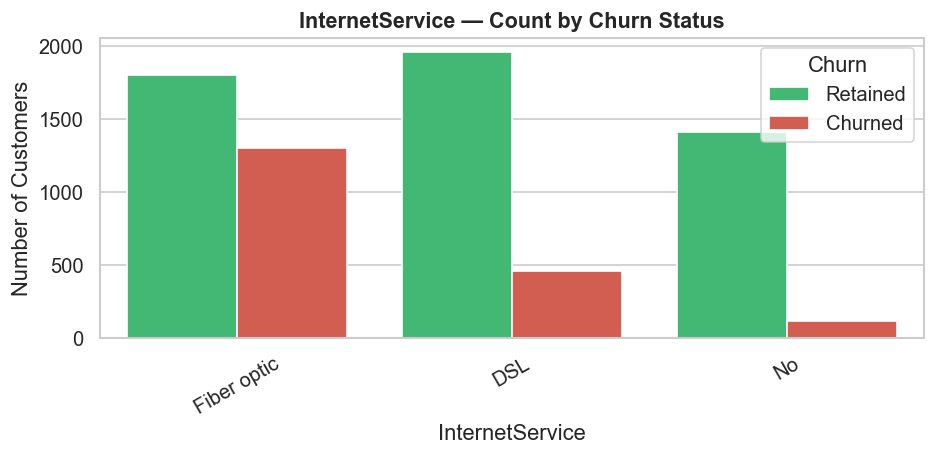

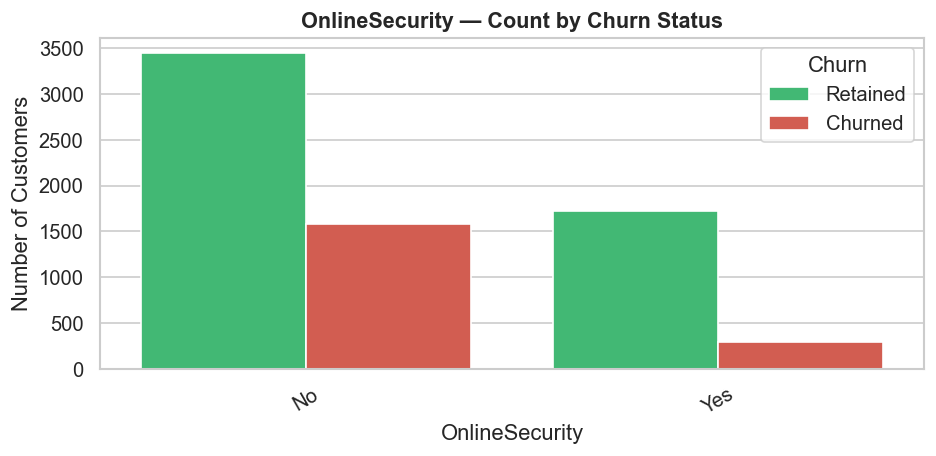

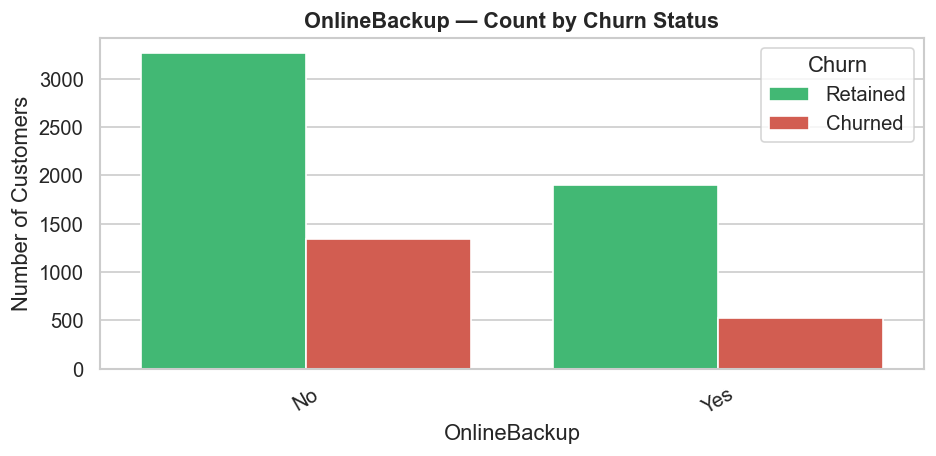

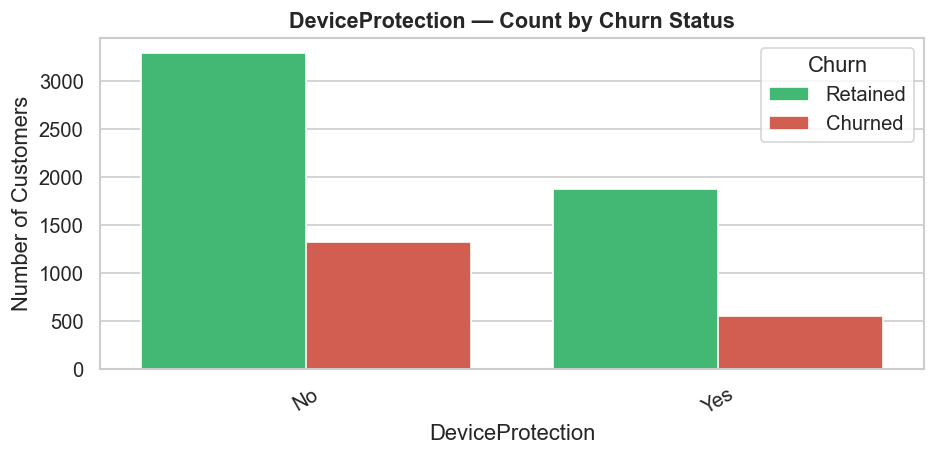

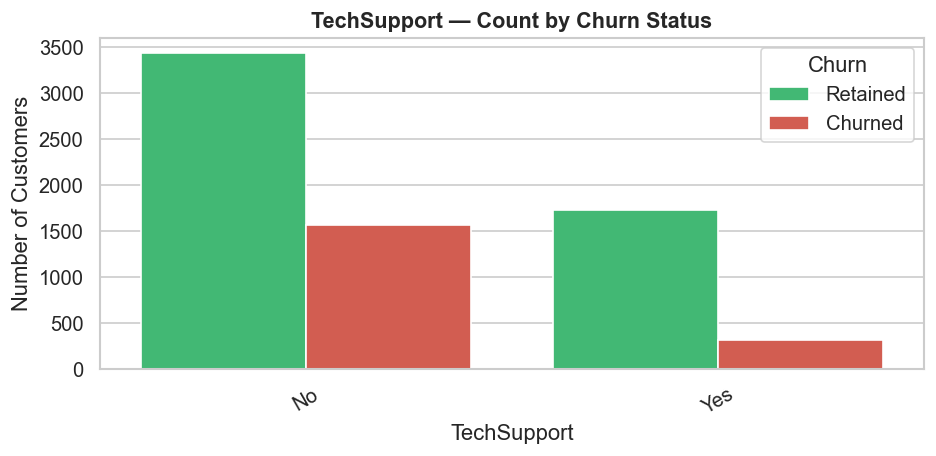

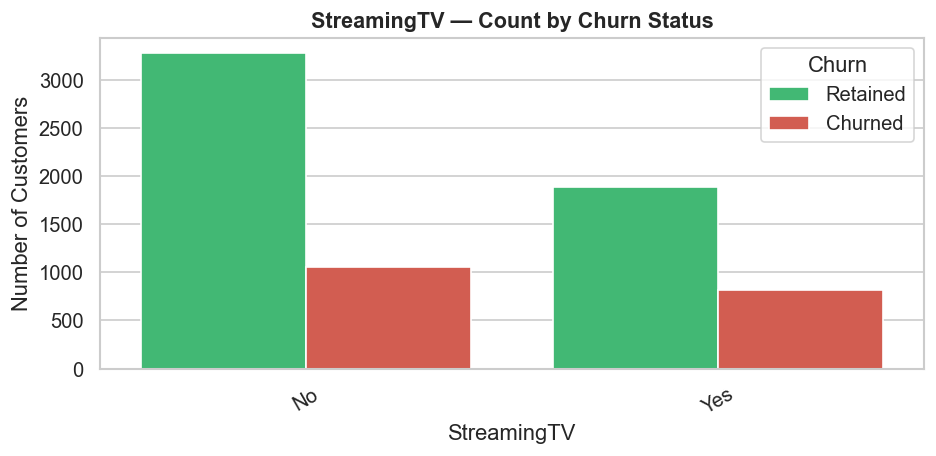

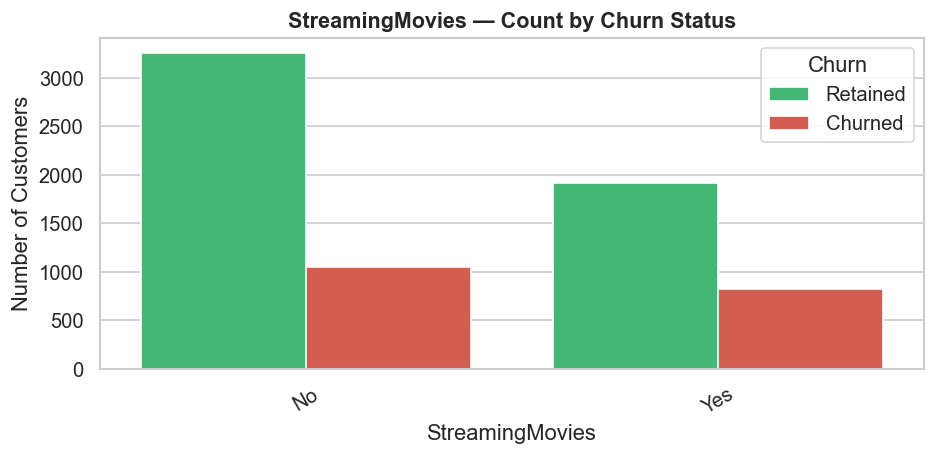

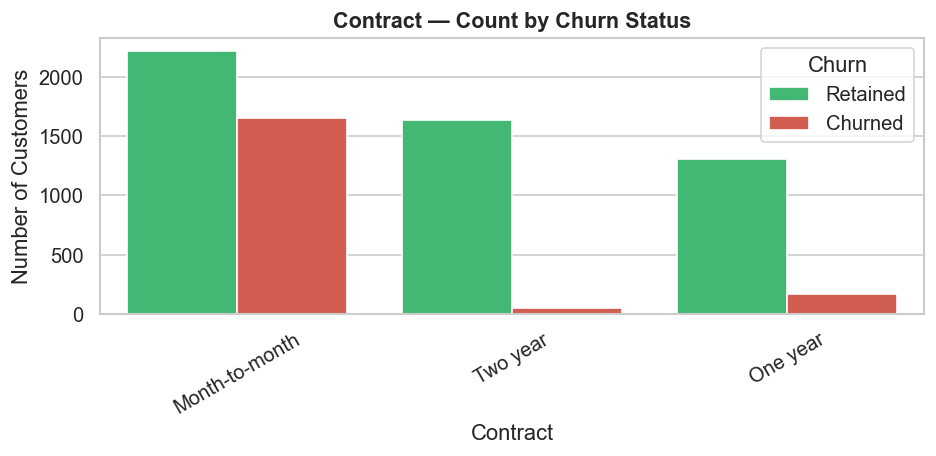

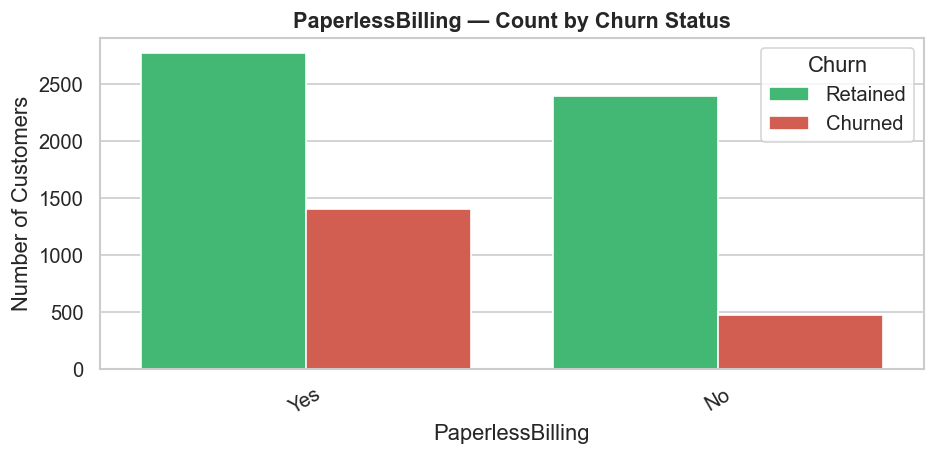

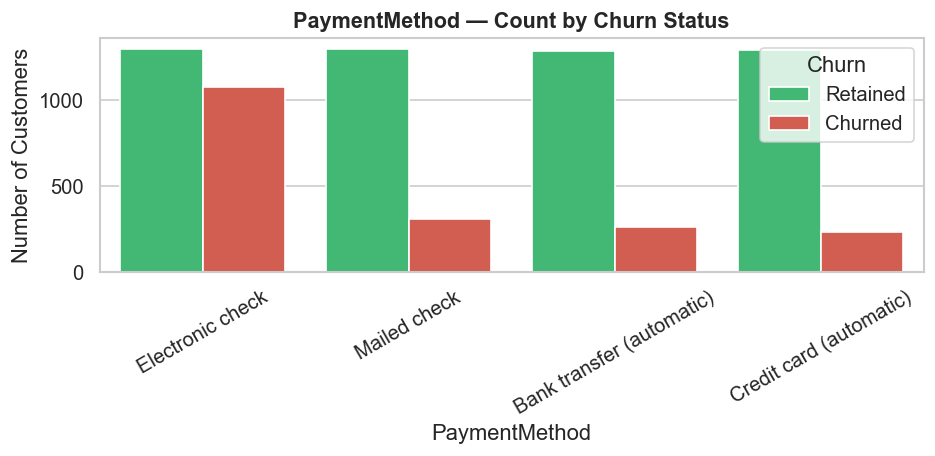

In [10]:
#Countplots showing churn breakdown within each category 
for col in categorical_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.countplot(x=col, hue='Churn', data=data,
                  palette=CHURN_COLORS, order=data[col].value_counts().index, ax=ax)
    ax.set_title(f'{col} — Count by Churn Status', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Number of Customers')
    ax.legend(title='Churn', labels=['Retained', 'Churned'])
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

---
## 6. Churn Analysis — Key Drivers <a id='6'></a>

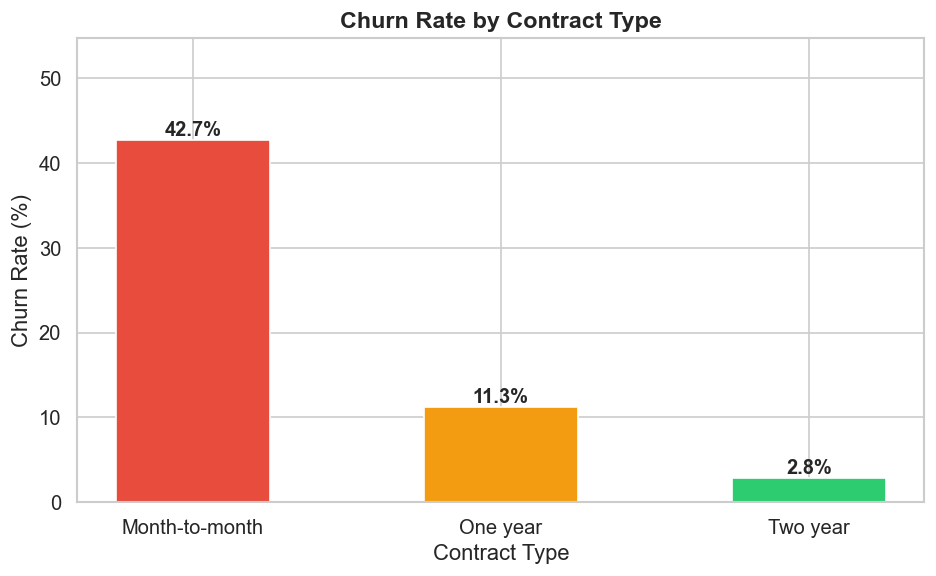

In [11]:
#Plot 1: Churn Rate by Contract Type
fig, ax = plt.subplots(figsize=(8, 5))
contract_churn = (data.groupby('Contract')['Churn_Binary'].mean() * 100
                  ).sort_values(ascending=False)

bars = ax.bar(contract_churn.index, contract_churn.values,
              color=['#e74c3c', '#f39c12', '#2ecc71'],
              edgecolor='white', width=0.5)
for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, contract_churn.max() + 12)
plt.tight_layout()
plt.show()

> **Key Insight:** Month-to-month customers churn at a dramatically higher rate than customers on longer contracts.

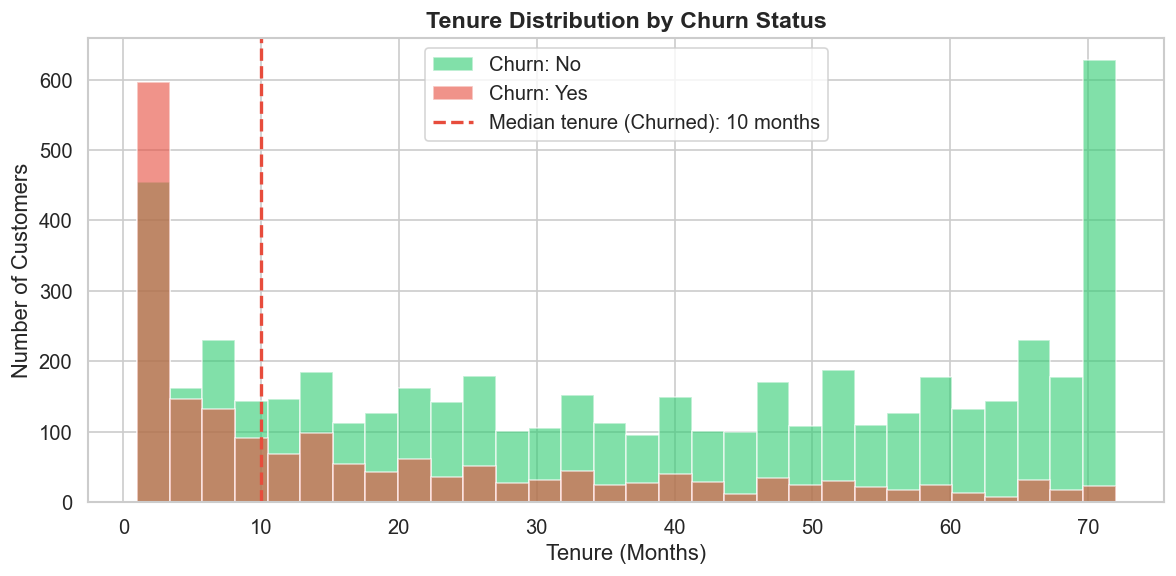

In [12]:
#Plot 2: Tenure vs Churn (Histogram Overlay)
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in zip(['No', 'Yes'], PALETTE):
    ax.hist(data[data['Churn'] == label]['tenure'],
            bins=30, alpha=0.6, label=f'Churn: {label}',
            color=color, edgecolor='white')

ax.axvline(data[data['Churn']=='Yes']['tenure'].median(),
           color='#e74c3c', linestyle='--', linewidth=2,
           label=f'Median tenure (Churned): {data[data["Churn"]=="Yes"]["tenure"].median():.0f} months')
ax.set_title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.show()

> **Key Insight:** Churned customers have significantly lower tenure — most churn happens in the first 12 months.

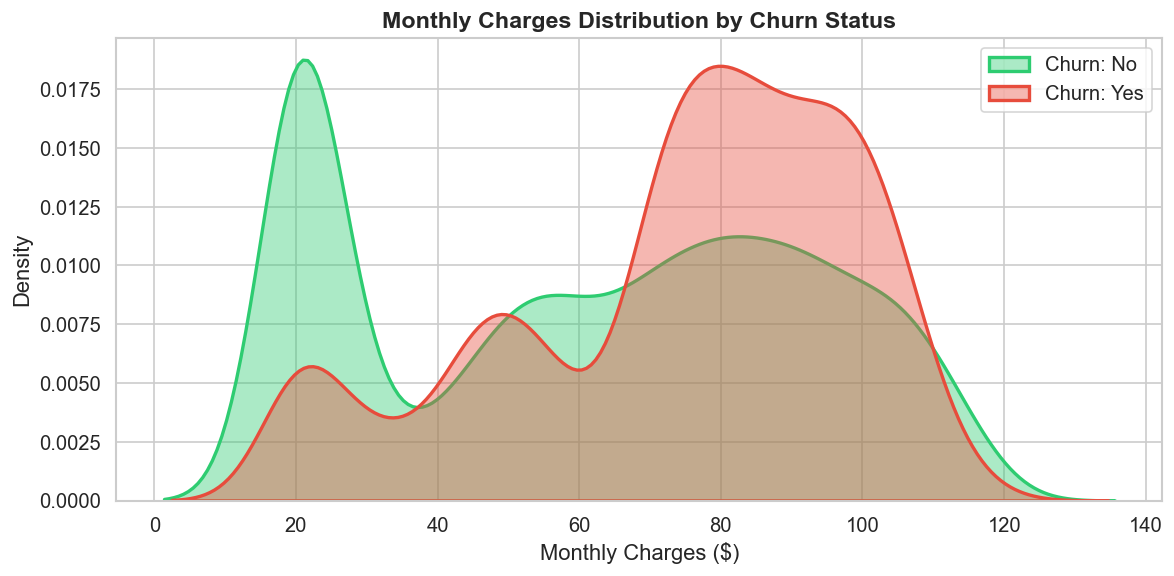

In [13]:
# Plot 3: Monthly Charges KDE by Churn
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in zip(['No', 'Yes'], PALETTE):
    sns.kdeplot(data[data['Churn'] == label]['MonthlyCharges'],
                ax=ax, label=f'Churn: {label}',
                color=color, fill=True, alpha=0.4, linewidth=2)

ax.set_title('Monthly Charges Distribution by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

> **Key Insight:** Customers paying higher monthly charges are more likely to churn.

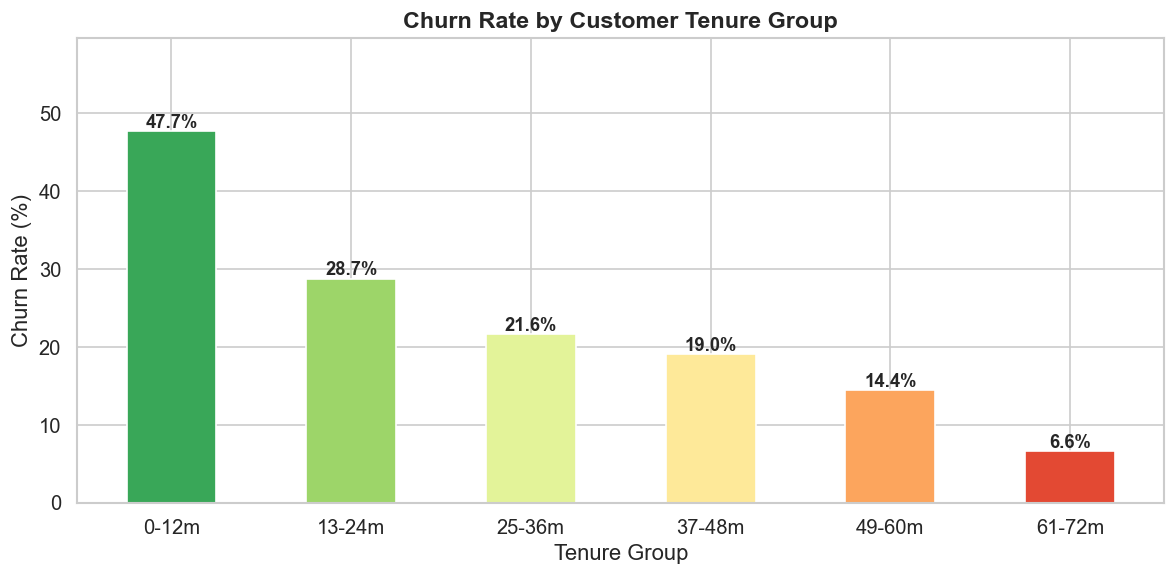

In [14]:
# Plot 4: Churn Rate by Tenure Cohort 
fig, ax = plt.subplots(figsize=(10, 5))
data['tenure_group'] = pd.cut(data['tenure'],
                               bins=[0, 12, 24, 36, 48, 60, 72],
                               labels=['0-12m', '13-24m', '25-36m',
                                       '37-48m', '49-60m', '61-72m'])
cohort = data.groupby('tenure_group', observed=True)['Churn_Binary'].mean() * 100

bars = ax.bar(cohort.index.astype(str), cohort.values,
              color=sns.color_palette('RdYlGn_r', len(cohort)),
              edgecolor='white', width=0.5)
for bar, val in zip(bars, cohort.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

ax.set_title('Churn Rate by Customer Tenure Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, cohort.max() + 12)
plt.tight_layout()
plt.show()

> **Key Insight:** Churn rate drops sharply after the first year. Retention efforts should focus on new customers (0-12 months).

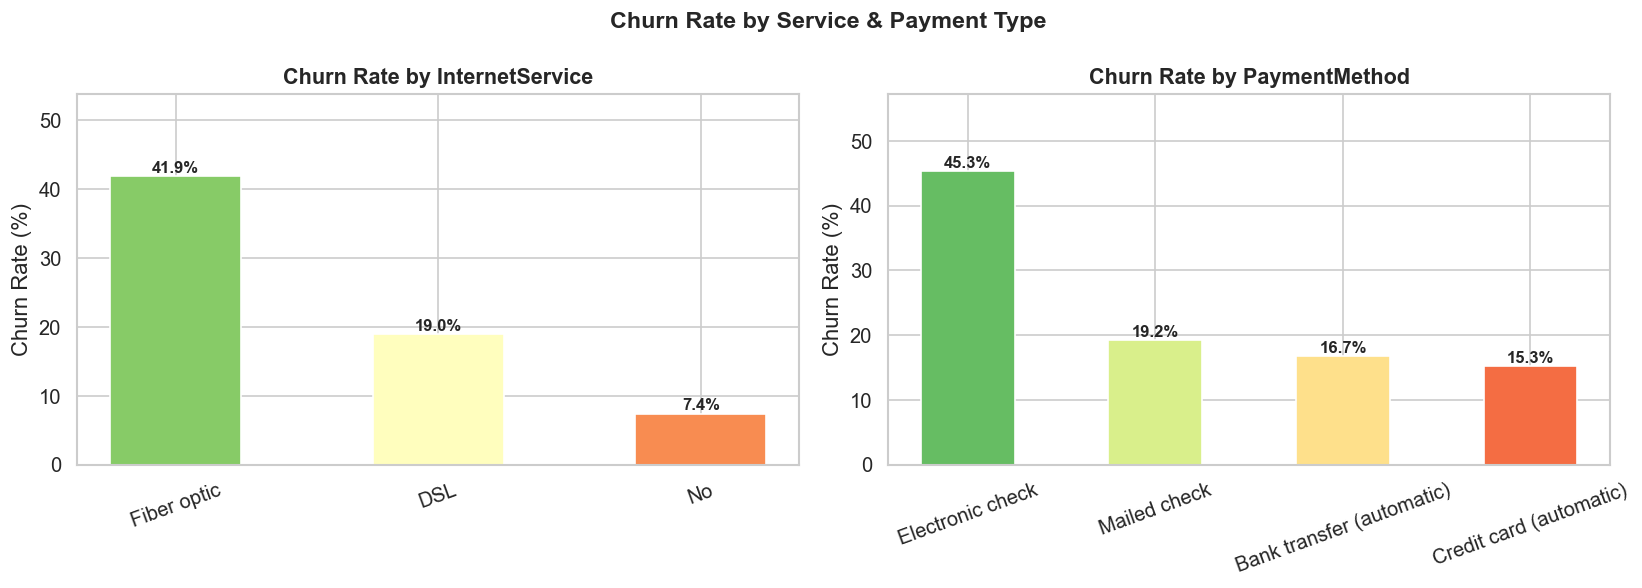

In [15]:
#  Plot 5: Churn Rate by Internet & Payment Method 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['InternetService', 'PaymentMethod']):
    churn_rate = (data.groupby(col)['Churn_Binary'].mean() * 100
                  ).sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color=sns.color_palette('RdYlGn_r', len(churn_rate)),
                  edgecolor='white', width=0.5)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
    ax.set_title(f'Churn Rate by {col}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, churn_rate.max() + 12)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Churn Rate by Service & Payment Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

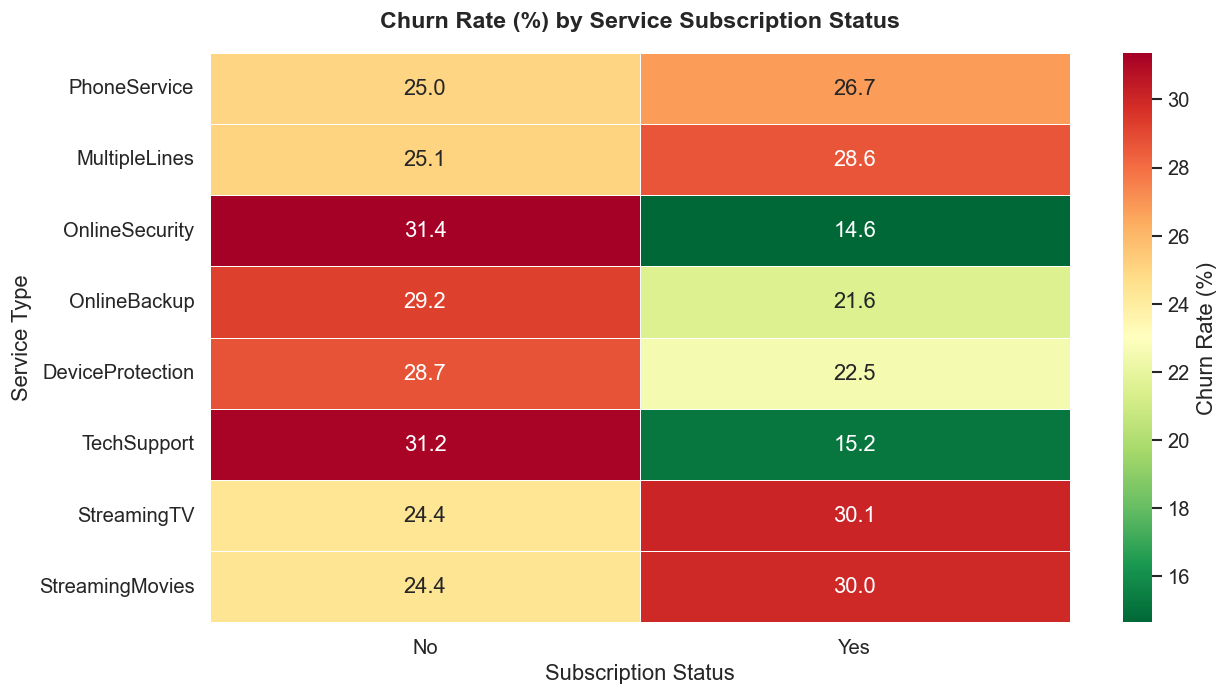

In [16]:
#  Plot 6: Service Subscription Churn Heatmap 
fig, ax = plt.subplots(figsize=(11, 6))
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

churn_rates = {col: data.groupby(col)['Churn_Binary'].mean() * 100
               for col in service_cols}
churn_df = pd.DataFrame(churn_rates).T

sns.heatmap(churn_df, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate (%) by Service Subscription Status',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Subscription Status')
ax.set_ylabel('Service Type')
plt.tight_layout()
plt.show()

> **Key Insight:** Customers without OnlineSecurity and TechSupport churn at significantly higher rates — these services act as retention anchors.

---
## 7. Correlation Analysis <a id='7'></a>

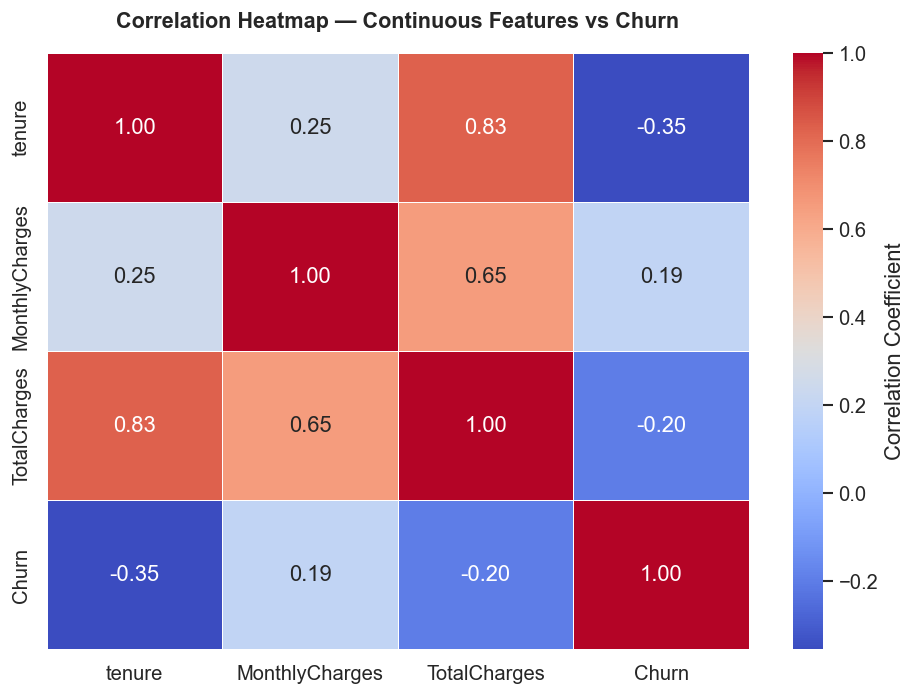


Correlation with Churn:
MonthlyCharges    0.192858
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn, dtype: float64


In [17]:
# Correlation Heatmap (continuous features + Churn) 
fig, ax = plt.subplots(figsize=(8, 6))
corr_data = data[continuous_cols].copy()
corr_data['Churn'] = data['Churn_Binary']

sns.heatmap(corr_data.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Correlation Heatmap — Continuous Features vs Churn',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\nCorrelation with Churn:')
print(corr_data.corr()['Churn'].drop('Churn').sort_values(ascending=False))

---
## 8. Key Findings Summary <a id='8'></a>

  1. CLASS IMBALANCE                                      
     ~26.5% churn rate — model needs class balancing      
                                                          
  2. CONTRACT TYPE (Strongest Signal)                     
     Month-to-month customers churn at ~42%               
     vs ~11% (1yr) and ~3% (2yr)                          
                                                          
  3. TENURE                                               
     Most churn happens in first 12 months                
     Churn drops sharply after year 1                     
                                                          
  4. MONTHLY CHARGES                                      
     Higher charges correlate with more churn             
                                                          
  5. SERVICES                                             
     No OnlineSecurity / TechSupport = higher churn       
     Fiber optic customers churn more than DSL            
                                                          
  6. PAYMENT METHOD                                       
     Electronic check users churn the most   